# FaintGuard — Vision Model v3
## YOLOv11 Pose + BiLSTM — Multi-Output
**Outputs:** fall_score · lying_score · consciousness_prob · vision_risk_score
**Dataset:** UR Fall Detection (cam0 RGB)
**New features:** geometric angles · bbox tracking · multi-output head

In [2]:
# ── 0. Install ──────────────────────────────────────────────
!pip install ultralytics --quiet
!pip install tensorflow --quiet

import os, cv2, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import deque

from ultralytics import YOLO

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Bidirectional, Dense, Dropout,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings('ignore')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
TensorFlow : 2.19.0
GPU available: True


In [3]:
# ── 1. Config ───────────────────────────────────────────────
BASE_PATH = '/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb'
LABELS_DIR = '/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset'

SEQ_LEN  = 30    # frames par séquence
STRIDE   = 8     # sliding window stride
CONF     = 0.35  # YOLO confidence threshold
EPOCHS   = 80
BATCH    = 16
SEED     = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

fall_dirs = sorted([d for d in os.listdir(BASE_PATH) if d.startswith('fall')])
adl_dirs  = sorted([d for d in os.listdir(BASE_PATH) if d.startswith('adl')])
print(f'Falls : {len(fall_dirs)} | ADL : {len(adl_dirs)}')

Falls : 30 | ADL : 40


In [4]:
# ── 2. Load YOLO ────────────────────────────────────────────
yolo = YOLO('yolo11n-pose.pt')
print('YOLOv11 Pose loaded')

YOLOv11 Pose loaded


In [5]:
# ── 3. Load frame-level labels from URFD CSV ────────────────
# Label: -1 = not lying, 0 = falling (transition), 1 = lying
# We download these from the official URFD source

import urllib.request

os.makedirs('/kaggle/working/labels', exist_ok=True)

BASE_URL = 'https://fenix.ur.edu.pl/~mkepski/ds/data'
frame_labels = {}  # {seq_name: {frame_num: label}}

for fname, prefix in [('urfall-cam0-falls.csv', 'fall'), ('urfall-cam0-adls.csv', 'adl')]:
    local = f'/kaggle/working/labels/{fname}'
    if not os.path.exists(local):
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(f'{BASE_URL}/{fname}', local)
    df = pd.read_csv(local, header=None)
    for seq_name, group in df.groupby(0):
        frame_labels[str(seq_name)] = {}
        for _, row in group.iterrows():
            frame_labels[str(seq_name)][int(row[1])] = int(row[2])

print(f'Sequences with frame labels: {len(frame_labels)}')
print(f'Example — fall-01 labels: {list(frame_labels.get("fall-01", {}).items())[:5]}')

Sequences with frame labels: 70
Example — fall-01 labels: [(1, -1), (2, -1), (3, -1), (4, -1), (5, -1)]


In [6]:
# ── 4. Geometric Feature Engineering ────────────────────────
# YOLO keypoint indices (COCO 17 keypoints)
# 0=nose, 1=left_eye, 2=right_eye, 3=left_ear, 4=right_ear
# 5=left_shoulder, 6=right_shoulder, 7=left_elbow, 8=right_elbow
# 9=left_wrist, 10=right_wrist, 11=left_hip, 12=right_hip
# 13=left_knee, 14=right_knee, 15=left_ankle, 16=right_ankle

L_SHOULDER, R_SHOULDER = 5, 6
L_HIP, R_HIP           = 11, 12
L_KNEE, R_KNEE         = 13, 14
L_ANKLE, R_ANKLE       = 15, 16
NOSE                   = 0

def compute_angle(a, b, c):
    """Angle at point b formed by a-b-c. Returns degrees."""
    v1 = a - b
    v2 = c - b
    cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)
    return float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))

def extract_geometric_features(kpts_xy, kpts_conf, bbox, frame_h, frame_w):
    """
    kpts_xy   : (17, 2) normalized [0,1]
    kpts_conf : (17,)   confidence scores
    bbox      : (4,) [x1,y1,x2,y2] normalized
    Returns   : (N,) feature vector
    """
    features = []

    # ── 1. Raw keypoints + confidence (51 features) ──────────
    kpts_flat = np.concatenate([kpts_xy.flatten(), kpts_conf])  # 34 + 17 = 51
    features.extend(kpts_flat.tolist())

    # ── 2. BBox features (5 features) ───────────────────────
    if bbox is not None and len(bbox) == 4:
        bx1, by1, bx2, by2 = bbox
        bw   = bx2 - bx1
        bh   = by2 - by1
        bcx  = (bx1 + bx2) / 2  # center x
        bcy  = (by1 + by2) / 2  # center y
        ar   = bw / (bh + 1e-6)  # aspect ratio — high when lying
        features.extend([bcx, bcy, bw, bh, ar])
    else:
        features.extend([0.5, 0.5, 0.3, 0.6, 0.5])

    # ── 3. Torso angle (2 features) ─────────────────────────
    # Angle between shoulder-hip vector and vertical
    sh_mid  = 0.5 * (kpts_xy[L_SHOULDER] + kpts_xy[R_SHOULDER])
    hip_mid = 0.5 * (kpts_xy[L_HIP]      + kpts_xy[R_HIP])
    torso_v = sh_mid - hip_mid
    torso_norm = np.linalg.norm(torso_v) + 1e-6
    # cos with vertical (0,1)
    cos_vert = abs(torso_v[1]) / torso_norm  # 1 = upright, 0 = horizontal
    sin_vert = abs(torso_v[0]) / torso_norm  # 1 = horizontal (lying)
    features.extend([cos_vert, sin_vert])

    # ── 4. Head position relative to hip (2 features) ───────
    # When unconscious/lying: head close to hip level
    nose = kpts_xy[NOSE]
    head_hip_dy = abs(nose[1] - hip_mid[1])   # small = head low = unconscious
    head_hip_dx = abs(nose[0] - hip_mid[0])
    features.extend([head_hip_dy, head_hip_dx])

    # ── 5. Knee angle (2 features) ──────────────────────────
    # Straight legs = standing/lying, bent = sitting/crouching
    # Left knee
    if (kpts_conf[L_HIP] > 0.3 and kpts_conf[L_KNEE] > 0.3 and kpts_conf[L_ANKLE] > 0.3):
        left_knee_angle  = compute_angle(kpts_xy[L_HIP], kpts_xy[L_KNEE], kpts_xy[L_ANKLE]) / 180.0
    else:
        left_knee_angle  = 0.5
    if (kpts_conf[R_HIP] > 0.3 and kpts_conf[R_KNEE] > 0.3 and kpts_conf[R_ANKLE] > 0.3):
        right_knee_angle = compute_angle(kpts_xy[R_HIP], kpts_xy[R_KNEE], kpts_xy[R_ANKLE]) / 180.0
    else:
        right_knee_angle = 0.5
    features.extend([left_knee_angle, right_knee_angle])

    # ── 6. Body height ratio (1 feature) ────────────────────
    # Ratio of detected body height vs frame height
    # Small when lying (body is horizontal, less vertical span)
    if bbox is not None:
        body_height_ratio = (bbox[3] - bbox[1])  # already normalized
    else:
        body_height_ratio = 0.5
    features.append(body_height_ratio)

    # Total: 51 + 5 + 2 + 2 + 2 + 1 = 63 features
    return np.array(features, dtype=np.float32)


# Test
dummy_kpts = np.random.rand(17, 2)
dummy_conf = np.random.rand(17)
dummy_bbox = np.array([0.1, 0.1, 0.4, 0.9])
feat = extract_geometric_features(dummy_kpts, dummy_conf, dummy_bbox, 480, 320)
print(f'Feature vector size: {len(feat)} features per frame')

Feature vector size: 63 features per frame


In [7]:
# ── 5. Process all sequences ─────────────────────────────────
FEAT_DIM = 63

def process_folder(folder_path, seq_name, label_dict):
    """
    Processes all PNG frames in a folder.
    Returns:
        kp_seq       : (T, 63) feature array
        frame_labels : (T,) array of posture labels (-1, 0, 1)
        bbox_centers : (T, 2) array of bbox centers for tracking
    """
    images = sorted([f for f in os.listdir(folder_path)
                     if f.lower().endswith(('.png', '.jpg'))])
    if not images:
        return None, None, None

    kp_seq       = []
    pose_labels  = []
    bbox_centers = []

    for img_file in images:
        # Extract frame number from filename
        # e.g. fall-01-cam0-rgb-001.png → frame 1
        parts = os.path.splitext(img_file)[0].split('-')
        try:
            frame_num = int(parts[-1])
        except:
            frame_num = -1

        frame = cv2.imread(os.path.join(folder_path, img_file))
        if frame is None:
            kp_seq.append(np.zeros(FEAT_DIM))
            pose_labels.append(-1)
            bbox_centers.append(np.array([0.5, 0.5]))
            continue

        h, w = frame.shape[:2]
        results = yolo(frame, verbose=False, conf=CONF, device='cpu')

        if (results[0].keypoints is not None and
            len(results[0].keypoints.xy) > 0 and
            results[0].boxes is not None and
            len(results[0].boxes.xyxy) > 0):

            # Keypoints
            kpts_xy   = results[0].keypoints.xy[0].cpu().numpy()    # (17, 2)
            kpts_conf = results[0].keypoints.conf[0].cpu().numpy()  # (17,)
            kpts_xy[:, 0] /= w
            kpts_xy[:, 1] /= h

            # Bounding box
            box = results[0].boxes.xyxy[0].cpu().numpy()  # [x1,y1,x2,y2]
            bbox_norm = np.array([box[0]/w, box[1]/h, box[2]/w, box[3]/h])
            bcx = (bbox_norm[0] + bbox_norm[2]) / 2
            bcy = (bbox_norm[1] + bbox_norm[3]) / 2

            feat = extract_geometric_features(kpts_xy, kpts_conf, bbox_norm, h, w)
            kp_seq.append(feat)
            bbox_centers.append(np.array([bcx, bcy]))
        else:
            kp_seq.append(np.zeros(FEAT_DIM))
            bbox_centers.append(np.array([0.5, 0.5]))

        # Frame-level posture label
        pose_label = label_dict.get(frame_num, -1)
        pose_labels.append(pose_label)

    return (
        np.array(kp_seq,       dtype=np.float32),
        np.array(pose_labels,  dtype=np.int8),
        np.array(bbox_centers, dtype=np.float32)
    )


# Process all sequences
all_kp_seqs     = []
all_pose_labels = []
all_bbox_seqs   = []
all_class       = []  # 0=ADL, 1=FALL
all_seq_names   = []

for split_name, dirs, cls in [('falls', fall_dirs, 1), ('adl', adl_dirs, 0)]:
    print(f'\nProcessing {len(dirs)} {split_name} sequences...')
    for seq_dir in tqdm(dirs):
        folder = os.path.join(BASE_PATH, seq_dir)
        # seq_name for label lookup: 'fall-01-cam0-rgb' → 'fall-01'
        seq_name = seq_dir.replace('-cam0-rgb', '')
        label_d  = frame_labels.get(seq_name, {})

        kp_seq, pose_lbl, bbox_seq = process_folder(folder, seq_name, label_d)
        if kp_seq is None or len(kp_seq) < SEQ_LEN:
            continue

        all_kp_seqs.append(kp_seq)
        all_pose_labels.append(pose_lbl)
        all_bbox_seqs.append(bbox_seq)
        all_class.append(cls)
        all_seq_names.append(seq_name)

print(f'\nTotal sequences processed: {len(all_kp_seqs)}')


Processing 30 falls sequences...


100%|██████████| 30/30 [06:05<00:00, 12.18s/it]



Processing 40 adl sequences...


100%|██████████| 40/40 [18:33<00:00, 27.83s/it]


Total sequences processed: 70


In [8]:
# ── 6. Build Clips with Multi-Output Labels ──────────────────
# For each clip of SEQ_LEN frames, compute 3 labels:
#   fall_label    : 1 if sequence is from fall folder
#   lying_label   : 1 if majority of frames have posture label == 1
#   consciousness : 1 if person is mobile (not lying + moving)
#                   0 if lying still (unconscious estimate)

def compute_inactivity_features(bbox_centers_clip):
    """
    Computes bbox center velocity over the clip.
    Low velocity → immobile → potential unconscious
    Returns: mean_velocity (float)
    """
    if len(bbox_centers_clip) < 2:
        return 0.0
    diffs = np.linalg.norm(
        np.diff(bbox_centers_clip, axis=0), axis=1
    )
    return float(np.mean(diffs))


X_clips    = []
Y_fall     = []
Y_lying    = []
Y_consious = []

IMMOBILE_THRESH = 0.005  # bbox center movement < this = immobile

for i in range(len(all_kp_seqs)):
    kp_seq    = all_kp_seqs[i]
    pose_lbl  = all_pose_labels[i]
    bbox_seq  = all_bbox_seqs[i]
    cls       = all_class[i]
    T         = len(kp_seq)

    for start in range(0, T - SEQ_LEN + 1, STRIDE):
        clip_kp    = kp_seq[start:start + SEQ_LEN]    # (30, 63)
        clip_pose  = pose_lbl[start:start + SEQ_LEN]  # (30,)
        clip_bbox  = bbox_seq[start:start + SEQ_LEN]  # (30, 2)

        # Fall label: from sequence class
        fall_lbl = float(cls)

        # Lying label: majority of valid frames (not -1) are lying
        valid_frames = clip_pose[clip_pose != 0]  # exclude transitional
        if len(valid_frames) > 0:
            lying_ratio = float(np.mean(valid_frames == 1))
            lying_lbl   = 1.0 if lying_ratio > 0.4 else 0.0
        else:
            lying_lbl = 0.0

        # Consciousness: 1=conscious, 0=unconscious estimate
        # Estimated as: NOT (lying AND immobile)
        motion  = compute_inactivity_features(clip_bbox)
        immobile = motion < IMMOBILE_THRESH
        conscious_lbl = 0.0 if (lying_lbl > 0.5 and immobile) else 1.0

        X_clips.append(clip_kp)
        Y_fall.append(fall_lbl)
        Y_lying.append(lying_lbl)
        Y_consious.append(conscious_lbl)

X      = np.array(X_clips,    dtype=np.float32)
Y_fall = np.array(Y_fall,     dtype=np.float32)
Y_lyin = np.array(Y_lying,    dtype=np.float32)
Y_cons = np.array(Y_consious, dtype=np.float32)

print(f'X shape     : {X.shape}')
print(f'Y_fall      : {int(Y_fall.sum())} fall clips / {len(Y_fall)} total')
print(f'Y_lying     : {int(Y_lyin.sum())} lying clips / {len(Y_lyin)} total')
print(f'Y_conscious : {int(Y_cons.sum())} conscious clips / {len(Y_cons)} total')

X shape     : (1271, 30, 63)
Y_fall      : 279 fall clips / 1271 total
Y_lying     : 309 lying clips / 1271 total
Y_conscious : 1210 conscious clips / 1271 total


In [9]:
# ── 7. Train / Val Split ─────────────────────────────────────
# Split by index (sequence-level to avoid leakage)
n = len(X)
idx = np.arange(n)
np.random.shuffle(idx)
split = int(0.8 * n)
train_idx, val_idx = idx[:split], idx[split:]

X_train, X_val = X[train_idx], X[val_idx]
Yf_train, Yf_val = Y_fall[train_idx], Y_fall[val_idx]
Yl_train, Yl_val = Y_lyin[train_idx], Y_lyin[val_idx]
Yc_train, Yc_val = Y_cons[train_idx], Y_cons[val_idx]

print(f'Train clips : {len(X_train)}')
print(f'Val clips   : {len(X_val)}')
print(f'Train fall  : {int(Yf_train.sum())} / {len(Yf_train)}')
print(f'Val fall    : {int(Yf_val.sum())} / {len(Yf_val)}')

Train clips : 1016
Val clips   : 255
Train fall  : 226 / 1016
Val fall    : 53 / 255


In [10]:
# ── 8. Model — BiLSTM + Attention Multi-Output ───────────────

def build_model(seq_len=SEQ_LEN, feat_dim=FEAT_DIM, lstm_units=128, dropout=0.3):
    """
    Architecture:
    Input (30, 63)
        → Dense projection (63 → 128)       ← encode features
        → BiLSTM (128×2 = 256)              ← temporal patterns
        → Dropout
        → BiLSTM (64×2 = 128)               ← high-level abstraction
        → LayerNorm
        → GlobalAveragePooling1D            ← aggregate time
        ├── Dense(64) → fall_score          ← did they fall?
        ├── Dense(64) → lying_score         ← are they lying?
        └── Dense(64) → consciousness_prob  ← are they responsive?
    """
    inp = Input(shape=(seq_len, feat_dim), name='keypoints')

    # Feature projection
    x = Dense(128, activation='relu', name='feat_proj')(inp)
    x = Dropout(dropout)(x)

    # Bidirectional LSTM stack
    x = Bidirectional(LSTM(lstm_units, return_sequences=True,
                           dropout=dropout, recurrent_dropout=0.1),
                      name='bilstm_1')(x)
    x = Dropout(dropout)(x)

    x = Bidirectional(LSTM(lstm_units // 2, return_sequences=True,
                           dropout=dropout),
                      name='bilstm_2')(x)
    x = LayerNormalization()(x)

    # Global pooling
    pooled = GlobalAveragePooling1D(name='pool')(x)

    # ── Output heads ─────────────────────────────────────────
    # Fall head
    fall_x   = Dense(64, activation='relu', name='fall_dense')(pooled)
    fall_x   = Dropout(dropout * 0.5)(fall_x)
    fall_out = Dense(1, activation='sigmoid', name='fall_score')(fall_x)

    # Lying head
    lying_x   = Dense(64, activation='relu', name='lying_dense')(pooled)
    lying_x   = Dropout(dropout * 0.5)(lying_x)
    lying_out = Dense(1, activation='sigmoid', name='lying_score')(lying_x)

    # Consciousness head
    cons_x   = Dense(64, activation='relu', name='cons_dense')(pooled)
    cons_x   = Dropout(dropout * 0.5)(cons_x)
    cons_out = Dense(1, activation='sigmoid', name='consciousness_prob')(cons_x)

    model = Model(inputs=inp,
                  outputs=[fall_out, lying_out, cons_out],
                  name='FaintGuard_VisionModel')
    return model


model = build_model()
model.summary()

# Class weights for imbalanced outputs
n_fall    = int(Yf_train.sum())
n_no_fall = len(Yf_train) - n_fall
w_fall    = n_no_fall / (n_fall + 1e-6)
print(f'\nClass weight fall : {w_fall:.2f}')

I0000 00:00:1774825819.395863      56 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "FaintGuard_VisionModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ keypoints           │ (None, 30, 63)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_proj (Dense)   │ (None, 30, 128)   │      8,192 │ keypoints[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 128)   │          0 │ feat_proj[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 30, 256)   │    263,168 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 256)   │          0 │ bilstm_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 30, 128)   │    164,352 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 128)   │        256 │ bilstm_2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool                │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fall_dense (Dense)  │ (None, 64)        │      8,256 │ pool[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lying_dense (Dense) │ (None, 64)        │      8,256 │ pool[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cons_dense (Dense)  │ (None, 64)        │      8,256 │ pool[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ fall_dense[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ lying_dense[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ cons_dense[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fall_score (Dense)  │ (None, 1)         │         65 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lying_score (Dense) │ (None, 1)         │         65 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ consciousness_prob  │ (None, 1)         │         65 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 460,931 (1.76 MB)

 Trainable params: 460,931 (1.76 MB)

 Non-trainable params: 0 (0.00 B)


Class weight fall : 3.50


In [11]:
# ── 9. Compile & Train ───────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        'fall_score':         'binary_crossentropy',
        'lying_score':        'binary_crossentropy',
        'consciousness_prob': 'binary_crossentropy',
    },
    loss_weights={
        'fall_score':         2.0,   # priorité highest
        'lying_score':        1.5,
        'consciousness_prob': 1.0,
    },
    metrics={
        'fall_score':         ['accuracy', tf.keras.metrics.AUC(name='auc')],
        'lying_score':        ['accuracy'],
        'consciousness_prob': ['accuracy'],
    }
)

callbacks = [
    EarlyStopping(
        monitor='val_fall_score_auc', mode='max',
        patience=15, restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        'fall_detector_v3.keras', monitor='val_fall_score_auc',
        mode='max', save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_fall_score_auc', mode='max',
        factor=0.5, patience=7, verbose=1
    ),
]

history = model.fit(
    X_train,
    {'fall_score': Yf_train, 'lying_score': Yl_train, 'consciousness_prob': Yc_train},
    validation_data=(
        X_val,
        {'fall_score': Yf_val, 'lying_score': Yl_val, 'consciousness_prob': Yc_val}
    ),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=None,  # handled via loss_weights
    callbacks=callbacks,
    verbose=1
)

Epoch 1/80


I0000 00:00:1774825834.439918     193 cuda_dnn.cc:529] Loaded cuDNN version 91002


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - consciousness_prob_accuracy: 0.9414 - consciousness_prob_loss: 0.1746 - fall_score_accuracy: 0.7493 - fall_score_auc: 0.6608 - fall_score_loss: 0.5305 - loss: 1.7025 - lying_score_accuracy: 0.8721 - lying_score_loss: 0.3112
Epoch 1: val_fall_score_auc improved from -inf to 0.85746, saving model to fall_detector_v3.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 167ms/step - consciousness_prob_accuracy: 0.9418 - consciousness_prob_loss: 0.1739 - fall_score_accuracy: 0.7498 - fall_score_auc: 0.6618 - fall_score_loss: 0.5297 - loss: 1.6981 - lying_score_accuracy: 0.8727 - lying_score_loss: 0.3098 - val_consciousness_prob_accuracy: 0.9608 - val_consciousness_prob_loss: 0.1292 - val_fall_score_accuracy: 0.8667 - val_fall_score_auc: 0.8575 - val_fall_score_loss: 0.3387 - val_loss: 1.1450 - val_lying_score_accuracy: 0.9176 - val_lying_score_loss: 0.2258 - learning_rate: 0.0010
Epoch 2/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - consciousness_prob_accuracy: 0.

In [12]:
# ── 10. Evaluation ───────────────────────────────────────────
model.load_weights('fall_detector_v3.keras')

preds = model.predict(X_val, verbose=0)
p_fall = preds[0].flatten()
p_lyin = preds[1].flatten()
p_cons = preds[2].flatten()

# Vision risk score (fusion)
# Higher fall + lying + lower consciousness → higher risk
vision_risk = 0.5 * p_fall + 0.3 * p_lyin + 0.2 * (1 - p_cons)

print('\n=== FALL DETECTION ===')
y_pred_fall = (p_fall > 0.5).astype(int)
print(confusion_matrix(Yf_val, y_pred_fall))
print(classification_report(Yf_val, y_pred_fall,
      target_names=['No Fall', 'Fall'], zero_division=0))
print(f'ROC-AUC fall : {roc_auc_score(Yf_val, p_fall):.4f}')

print('\n=== LYING DETECTION ===')
y_pred_lyin = (p_lyin > 0.5).astype(int)
print(confusion_matrix(Yl_val, y_pred_lyin))
print(classification_report(Yl_val, y_pred_lyin,
      target_names=['Not Lying', 'Lying'], zero_division=0))

print('\n=== CONSCIOUSNESS ===')
y_pred_cons = (p_cons > 0.5).astype(int)
print(confusion_matrix(Yc_val, y_pred_cons))
print(classification_report(Yc_val, y_pred_cons,
      target_names=['Unconscious', 'Conscious'], zero_division=0))


=== FALL DETECTION ===
[[198   4]
 [  5  48]]
              precision    recall  f1-score   support

     No Fall       0.98      0.98      0.98       202
        Fall       0.92      0.91      0.91        53

    accuracy                           0.96       255
   macro avg       0.95      0.94      0.95       255
weighted avg       0.96      0.96      0.96       255

ROC-AUC fall : 0.9948

=== LYING DETECTION ===
[[178   8]
 [  6  63]]
              precision    recall  f1-score   support

   Not Lying       0.97      0.96      0.96       186
       Lying       0.89      0.91      0.90        69

    accuracy                           0.95       255
   macro avg       0.93      0.94      0.93       255
weighted avg       0.95      0.95      0.95       255


=== CONSCIOUSNESS ===
[[ 10   3]
 [  5 237]]
              precision    recall  f1-score   support

 Unconscious       0.67      0.77      0.71        13
   Conscious       0.99      0.98      0.98       242

    accuracy       

In [13]:
# ── 11. Threshold Analysis ───────────────────────────────────
from sklearn.metrics import f1_score, recall_score, precision_score

print(f'{"Threshold":>10} {"F1":>8} {"Recall":>8} {"Precision":>10} {"FP":>5} {"FN":>5}')
print('-' * 52)
for t in np.arange(0.2, 0.85, 0.05):
    yp  = (p_fall > t).astype(int)
    f1  = f1_score(Yf_val, yp, zero_division=0)
    rec = recall_score(Yf_val, yp, zero_division=0)
    pre = precision_score(Yf_val, yp, zero_division=0)
    fp  = int(((yp==1) & (Yf_val==0)).sum())
    fn  = int(((yp==0) & (Yf_val==1)).sum())
    print(f'{t:>10.2f} {f1:>8.3f} {rec:>8.3f} {pre:>10.3f} {fp:>5} {fn:>5}')

 Threshold       F1   Recall  Precision    FP    FN
----------------------------------------------------
      0.20    0.846    0.981      0.743    18     1
      0.25    0.881    0.981      0.800    13     1
      0.30    0.904    0.981      0.839    10     1
      0.35    0.904    0.981      0.839    10     1
      0.40    0.909    0.943      0.877     7     3
      0.45    0.907    0.925      0.891     6     4
      0.50    0.914    0.906      0.923     4     5
      0.55    0.931    0.887      0.979     1     6
      0.60    0.909    0.849      0.978     1     8
      0.65    0.898    0.830      0.978     1     9
      0.70    0.898    0.830      0.978     1     9
      0.75    0.884    0.792      1.000     0    11
      0.80    0.884    0.792      1.000     0    11


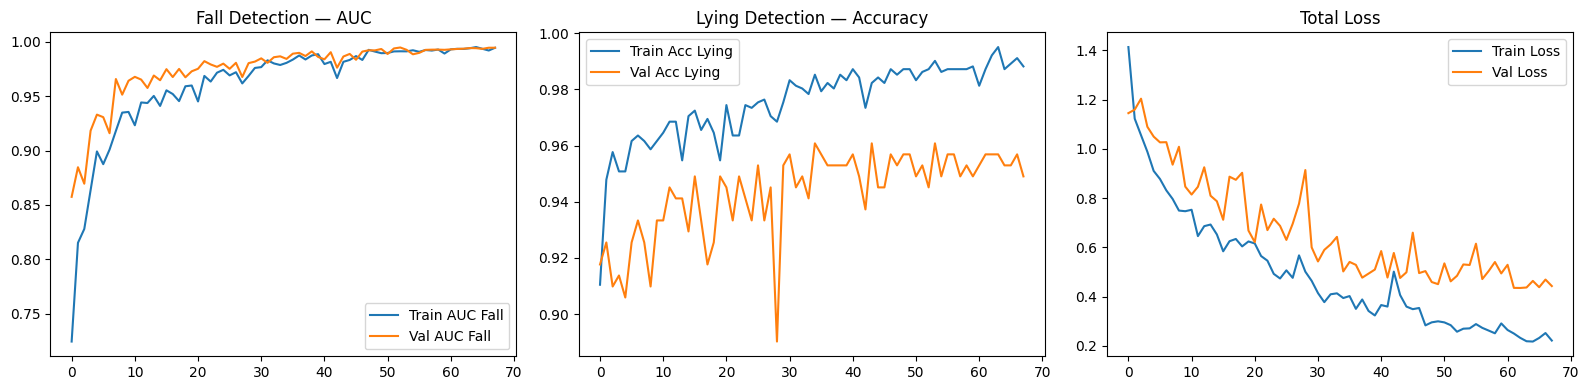

In [14]:
# ── 12. Training Curves ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history.get('fall_score_auc', []), label='Train AUC Fall')
axes[0].plot(history.history.get('val_fall_score_auc', []), label='Val AUC Fall')
axes[0].set_title('Fall Detection — AUC')
axes[0].legend()

axes[1].plot(history.history.get('lying_score_accuracy', []), label='Train Acc Lying')
axes[1].plot(history.history.get('val_lying_score_accuracy', []), label='Val Acc Lying')
axes[1].set_title('Lying Detection — Accuracy')
axes[1].legend()

axes[2].plot(history.history.get('loss', []), label='Train Loss')
axes[2].plot(history.history.get('val_loss', []), label='Val Loss')
axes[2].set_title('Total Loss')
axes[2].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()

In [15]:
# ── 13. Inference function (ready for VSCode) ─────────────────
OPTIMAL_THRESHOLD = 0.45  # update after threshold analysis above

def predict_vision_risk(frame_buffer, model, yolo_model,
                         threshold=OPTIMAL_THRESHOLD):
    """
    frame_buffer : list of last SEQ_LEN BGR frames from webcam
    Returns dict with all outputs for FaintGuard fusion.
    """
    if len(frame_buffer) < SEQ_LEN:
        return {
            'fall_score': 0.0, 'lying_score': 0.0,
            'consciousness_prob': 1.0, 'vision_risk_score': 0.0,
            'fall_detected': False, 'posture': 'unknown',
            'person_count': 0
        }

    clip_features = []
    person_counts = []
    bbox_centers  = []

    for frame in frame_buffer[-SEQ_LEN:]:
        h, w = frame.shape[:2]
        res  = yolo_model(frame, verbose=False, conf=0.35, device='cpu')
        person_counts.append(len(res[0].boxes) if res[0].boxes else 0)

        if (res[0].keypoints is not None and len(res[0].keypoints.xy) > 0
                and res[0].boxes is not None and len(res[0].boxes.xyxy) > 0):
            kpts_xy   = res[0].keypoints.xy[0].cpu().numpy()
            kpts_conf = res[0].keypoints.conf[0].cpu().numpy()
            kpts_xy[:, 0] /= w
            kpts_xy[:, 1] /= h
            box = res[0].boxes.xyxy[0].cpu().numpy()
            bbox_norm = np.array([box[0]/w, box[1]/h, box[2]/w, box[3]/h])
            bcx = (bbox_norm[0] + bbox_norm[2]) / 2
            bcy = (bbox_norm[1] + bbox_norm[3]) / 2
            feat = extract_geometric_features(kpts_xy, kpts_conf, bbox_norm, h, w)
            bbox_centers.append([bcx, bcy])
        else:
            feat = np.zeros(FEAT_DIM, dtype=np.float32)
            bbox_centers.append([0.5, 0.5])

        clip_features.append(feat)

    X_input = np.array(clip_features, dtype=np.float32)[np.newaxis]  # (1, 30, 63)
    preds   = model.predict(X_input, verbose=0)

    fall_score  = float(preds[0][0][0])
    lying_score = float(preds[1][0][0])
    cons_prob   = float(preds[2][0][0])

    # Inactivity
    bc_arr   = np.array(bbox_centers)
    motion   = compute_inactivity_features(bc_arr)
    immobile = motion < IMMOBILE_THRESH

    # Posture string
    if lying_score > 0.5:
        posture = 'lying'
    elif fall_score > threshold:
        posture = 'falling'
    else:
        posture = 'upright'

    # Vision risk score for fusion
    vision_risk = 0.5 * fall_score + 0.3 * lying_score + 0.2 * (1 - cons_prob)
    vision_risk = float(np.clip(vision_risk, 0.0, 1.0))

    return {
        'fall_score':         round(fall_score, 4),
        'lying_score':        round(lying_score, 4),
        'consciousness_prob': round(cons_prob, 4),
        'vision_risk_score':  round(vision_risk, 4),
        'fall_detected':      fall_score > threshold,
        'posture':            posture,
        'person_count':       int(np.mean(person_counts)),
        'inactive':           immobile,
        'motion':             round(float(motion), 6),
    }

print('predict_vision_risk() ready.')
print('Output format:')
print(json.dumps({
    'fall_score': 0.87, 'lying_score': 0.92,
    'consciousness_prob': 0.12, 'vision_risk_score': 0.78,
    'fall_detected': True, 'posture': 'lying',
    'person_count': 1, 'inactive': True, 'motion': 0.002
}, indent=2))

predict_vision_risk() ready.
Output format:
{
  "fall_score": 0.87,
  "lying_score": 0.92,
  "consciousness_prob": 0.12,
  "vision_risk_score": 0.78,
  "fall_detected": true,
  "posture": "lying",
  "person_count": 1,
  "inactive": true,
  "motion": 0.002
}


In [16]:
import os, json, zipfile
import tensorflow as tf

# ── 1. Sauvegarder le modèle ──────────────────────────────
ckpt_path = '/kaggle/working/fall_detector_v3.keras'
h5_path   = '/kaggle/working/fall_detector_v3.h5'

model.save(ckpt_path)
model.save(h5_path)
print(f"✅ .keras : {ckpt_path}")
print(f"✅ .h5    : {h5_path}")

# ── 2. Config JSON ────────────────────────────────────────
config = {
    "seq_len":         30,
    "feat_dim":        63,
    "conf_threshold":  0.35,
    "fall_threshold":  0.45,
    "immobile_thresh": 0.005,
    "yolo_model":      "yolo11n-pose.pt"
}
config_path = '/kaggle/working/vision_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✅ config : {config_path}")

# ── 3. ZIP ────────────────────────────────────────────────
zip_path = '/kaggle/working/faintguard_model.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fp in [ckpt_path, h5_path, config_path]:
        zf.write(fp, os.path.basename(fp))

print(f"\n📦 ZIP : {zip_path}  ({os.path.getsize(zip_path)/1024/1024:.1f} MB)")
print("📥 Output panel > faintguard_model.zip")

✅ .keras : /kaggle/working/fall_detector_v3.keras
✅ .h5    : /kaggle/working/fall_detector_v3.h5
✅ config : /kaggle/working/vision_config.json

📦 ZIP : /kaggle/working/faintguard_model.zip  (9.6 MB)
📥 Output panel > faintguard_model.zip
